Dataset overview

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler
import seaborn as sns
from sklearn.model_selection import train_test_split

In [168]:
df=pd.read_csv('/content/drive/MyDrive/ML_AL/House_Pricing.csv')
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
df.head()




,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [169]:
df.tail()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,Fair,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,Fair,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,Fair,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,Fair,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287
21612,1523300157,14 October 2017,325000.0,2,0.75,1020.0,1076.0,2.0,No,NaN,Fair,7,1020.0,0,10,0,98144.0,47.5941,-122.299,1020.0,1357


In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ID                                         21613 non-null  int64  
 1   Date House was Sold                        21613 non-null  object 
 2   Sale Price                                 21609 non-null  float64
 3   No of Bedrooms                             21613 non-null  int64  
 4   No of Bathrooms                            21609 non-null  float64
 5   Flat Area (in Sqft)                        21604 non-null  float64
 6   Lot Area (in Sqft)                         21604 non-null  float64
 7   No of Floors                               21613 non-null  float64
 8   Waterfront View                            21613 non-null  object 
 9   No of Times Visited                        2124 non-null   object 
 10  Condition of the House

In [171]:
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [172]:
df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


Duplicate removal

In [173]:
#duplicated rows
df.duplicated().sum()

np.int64(0)

In [174]:
#duplicated columns
df.T.duplicated().sum()

np.int64(0)

Handling missing values

In [175]:
#finding missing values
df.isna().sum()

,0
ID,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489


In [176]:
(df.isna().sum()/len(df)*100)

,0
ID,0.000000
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581


In [177]:
#dropping the column "no of time visited " becouse it has 90% missing values
df=(df.drop(columns=['No of Times Visited','ID']))

In [178]:
df.isna().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
Condition of the House,0
Overall Grade,0


In [179]:
#numerical values
numerical_columns=df.select_dtypes(include='number').columns

In [180]:
#categorical values
categorical_columns=df.select_dtypes(include="object").columns

Encoding

In [181]:
#spitting into month and year
df['Date House was Sold'] = pd.to_datetime(df['Date House was Sold'])

df['Year'] = df['Date House was Sold'].dt.year
df['Month'] = df['Date House was Sold'].dt.month

In [182]:
#label encoding
label_cols=['Condition of the House']
le=LabelEncoder()
for cols in label_cols:
  df[cols]=le.fit_transform(df[cols])

In [183]:
#onehotencoding for nominal categories
df = pd.get_dummies(df,columns=["Waterfront View"],drop_first=True,dtype=int)
df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft),Year,Month,Waterfront View_Yes
0,2017-10-14,221900.0,3,1.00,1180.0,5650.0,1.0,2,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650,2017,10,0
1,2017-12-14,538000.0,3,2.25,2570.0,7242.0,2.0,2,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639,2017,12,0
2,2016-02-15,180000.0,2,1.00,770.0,10000.0,1.0,2,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062,2016,2,0
3,2017-12-14,604000.0,4,3.00,1960.0,5000.0,1.0,1,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000,2017,12,0
4,2016-02-15,510000.0,3,2.00,1680.0,8080.0,1.0,2,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503,2016,2,0


Outlier removal

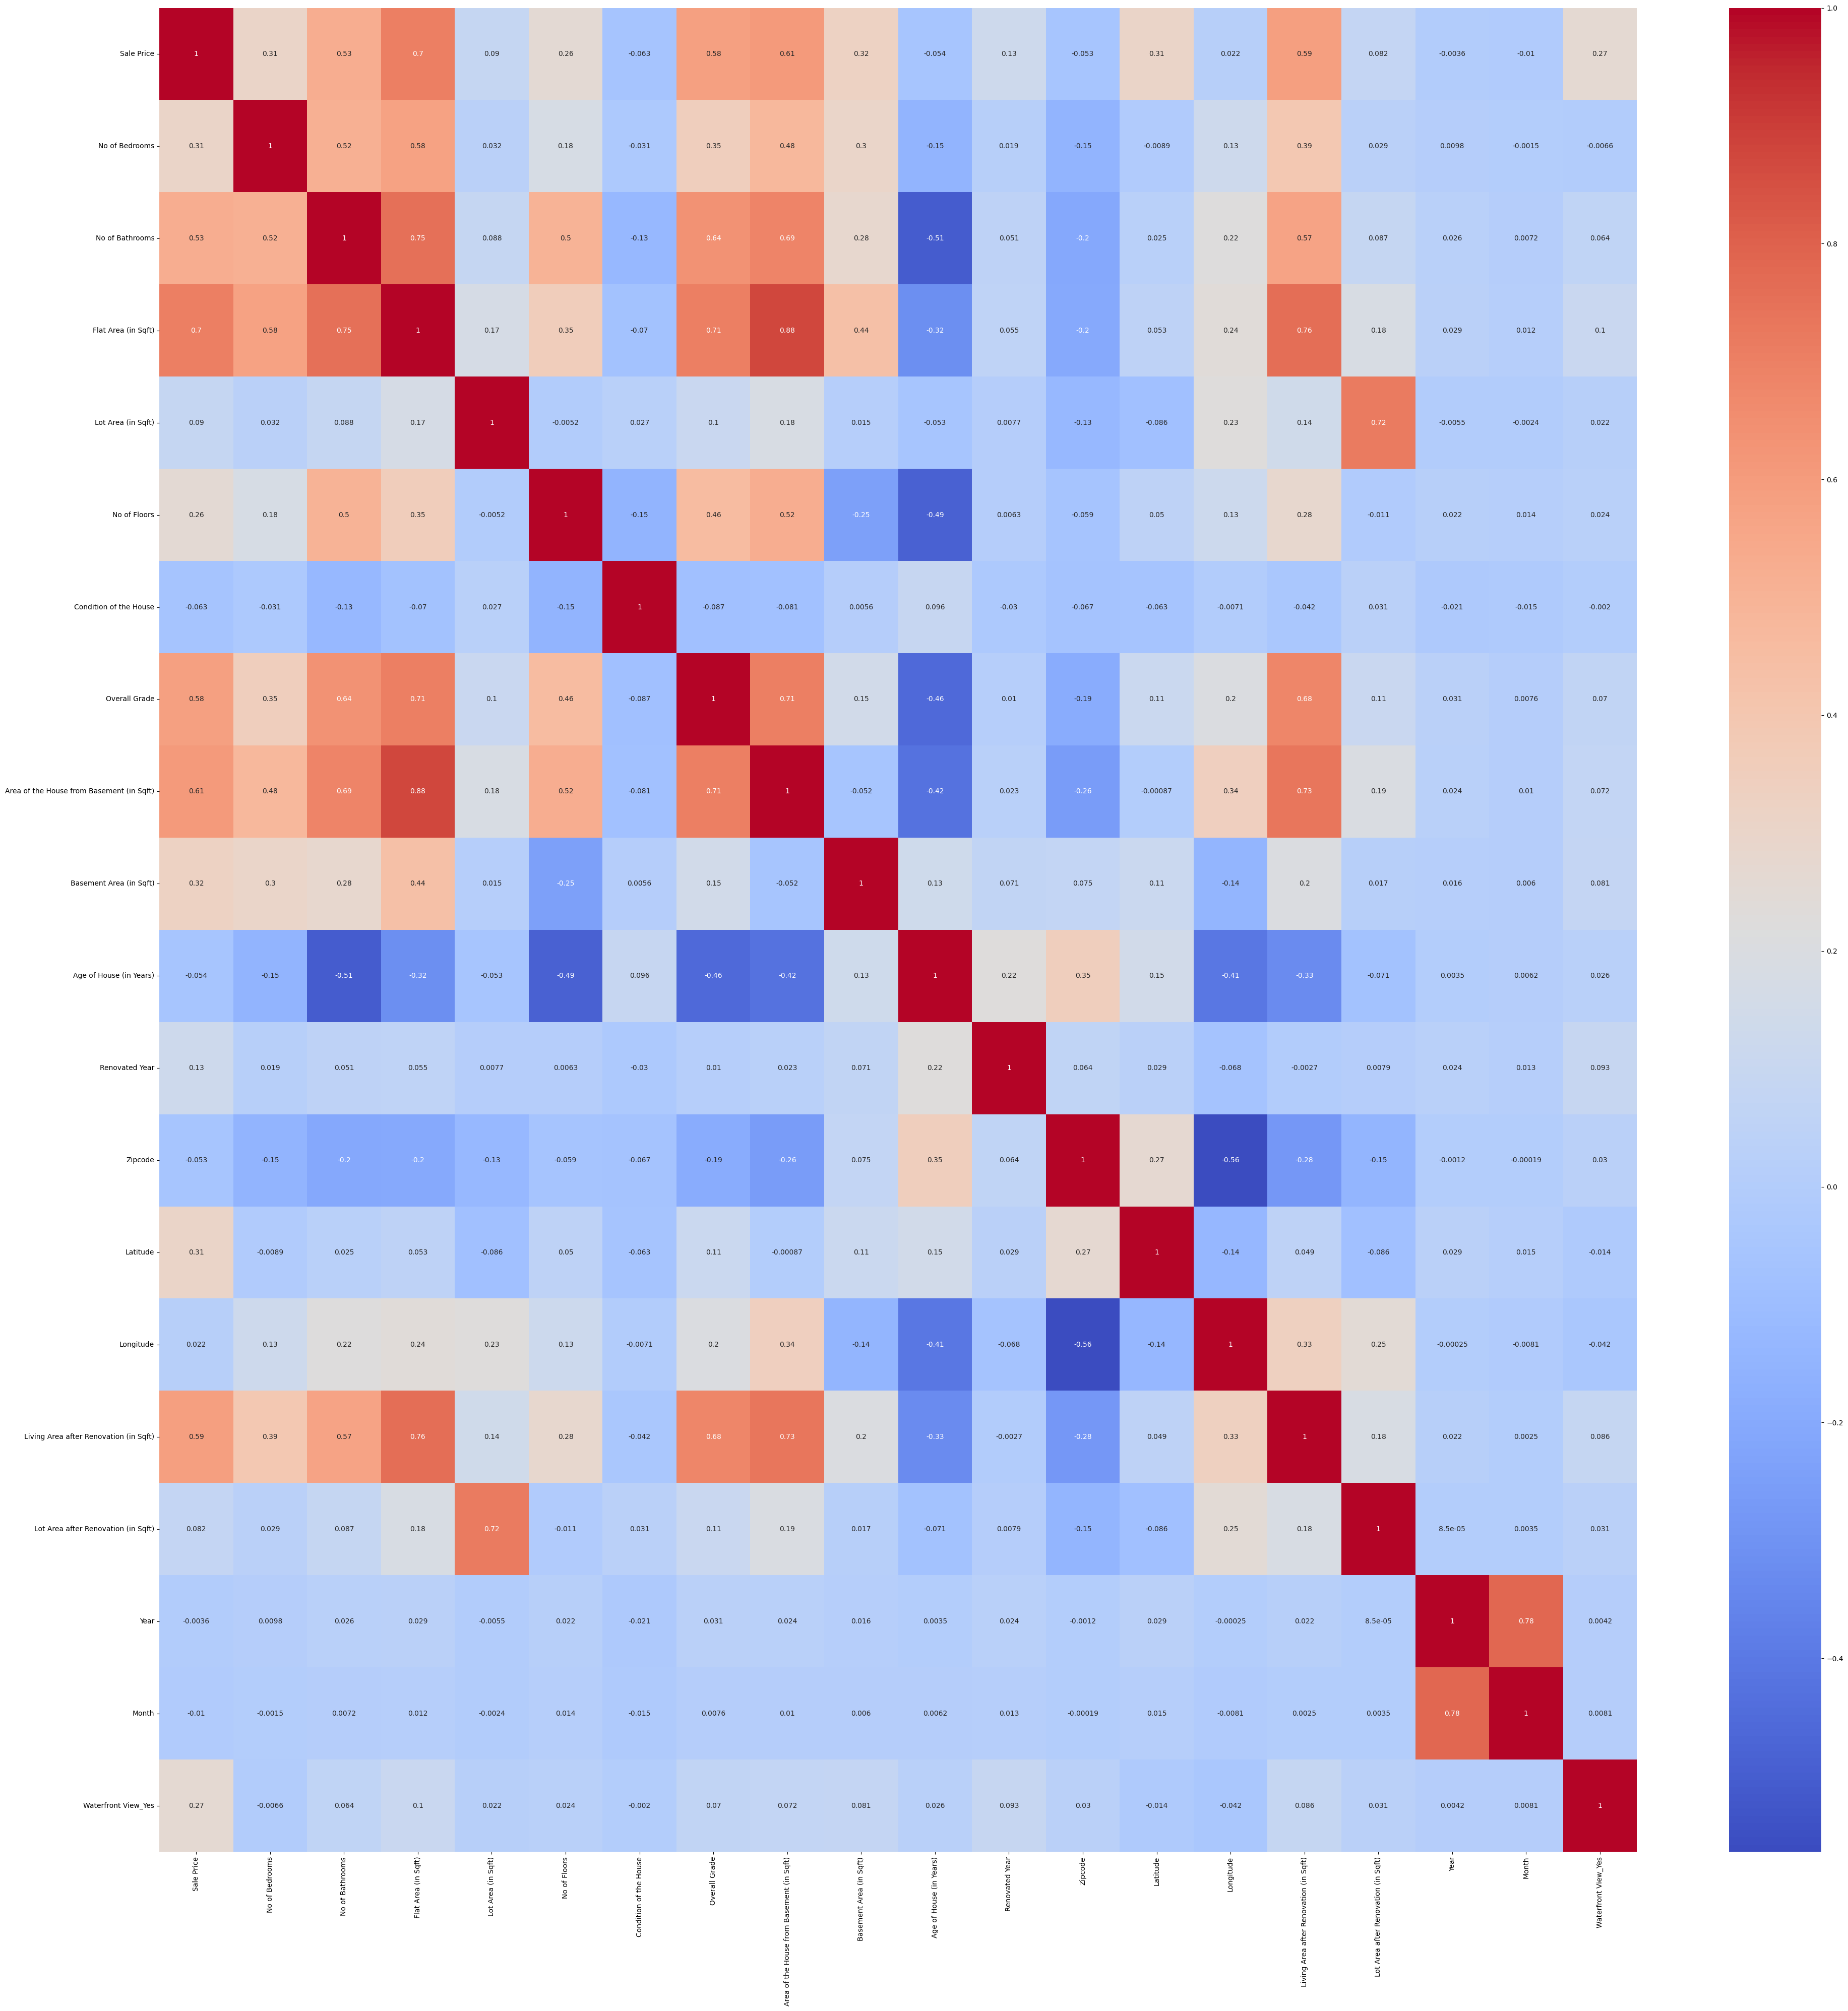

In [184]:
#correlation
corr_result = df.select_dtypes(include='number').corr()

plt.figure(figsize=(40,40))
sns.heatmap(
    corr_result,
    cmap="coolwarm",
    annot=True
)

plt.tight_layout()
plt.show()

In [185]:
df.columns.tolist()

['Date House was Sold',
 'Sale Price',
 'No of Bedrooms',
 'No of Bathrooms',
 'Flat Area (in Sqft)',
 'Lot Area (in Sqft)',
 'No of Floors',
 'Condition of the House',
 'Overall Grade',
 'Area of the House from Basement (in Sqft)',
 'Basement Area (in Sqft)',
 'Age of House (in Years)',
 'Renovated Year',
 'Zipcode',
 'Latitude',
 'Longitude',
 'Living Area after Renovation (in Sqft)',
 'Lot Area after Renovation (in Sqft)',
 'Year',
 'Month',
 'Waterfront View_Yes']

In [186]:
columns_to_select = [ 'Basement Area (in Sqft)', 'Living Area after Renovation (in Sqft)', 'Area of the House from Basement (in Sqft)', 'Sale Price'
]
columns_to_reject = [col for col in df.columns if col not in columns_to_select]
df=df.drop(columns=columns_to_reject)

In [187]:
columns_to_select.remove('Sale Price')

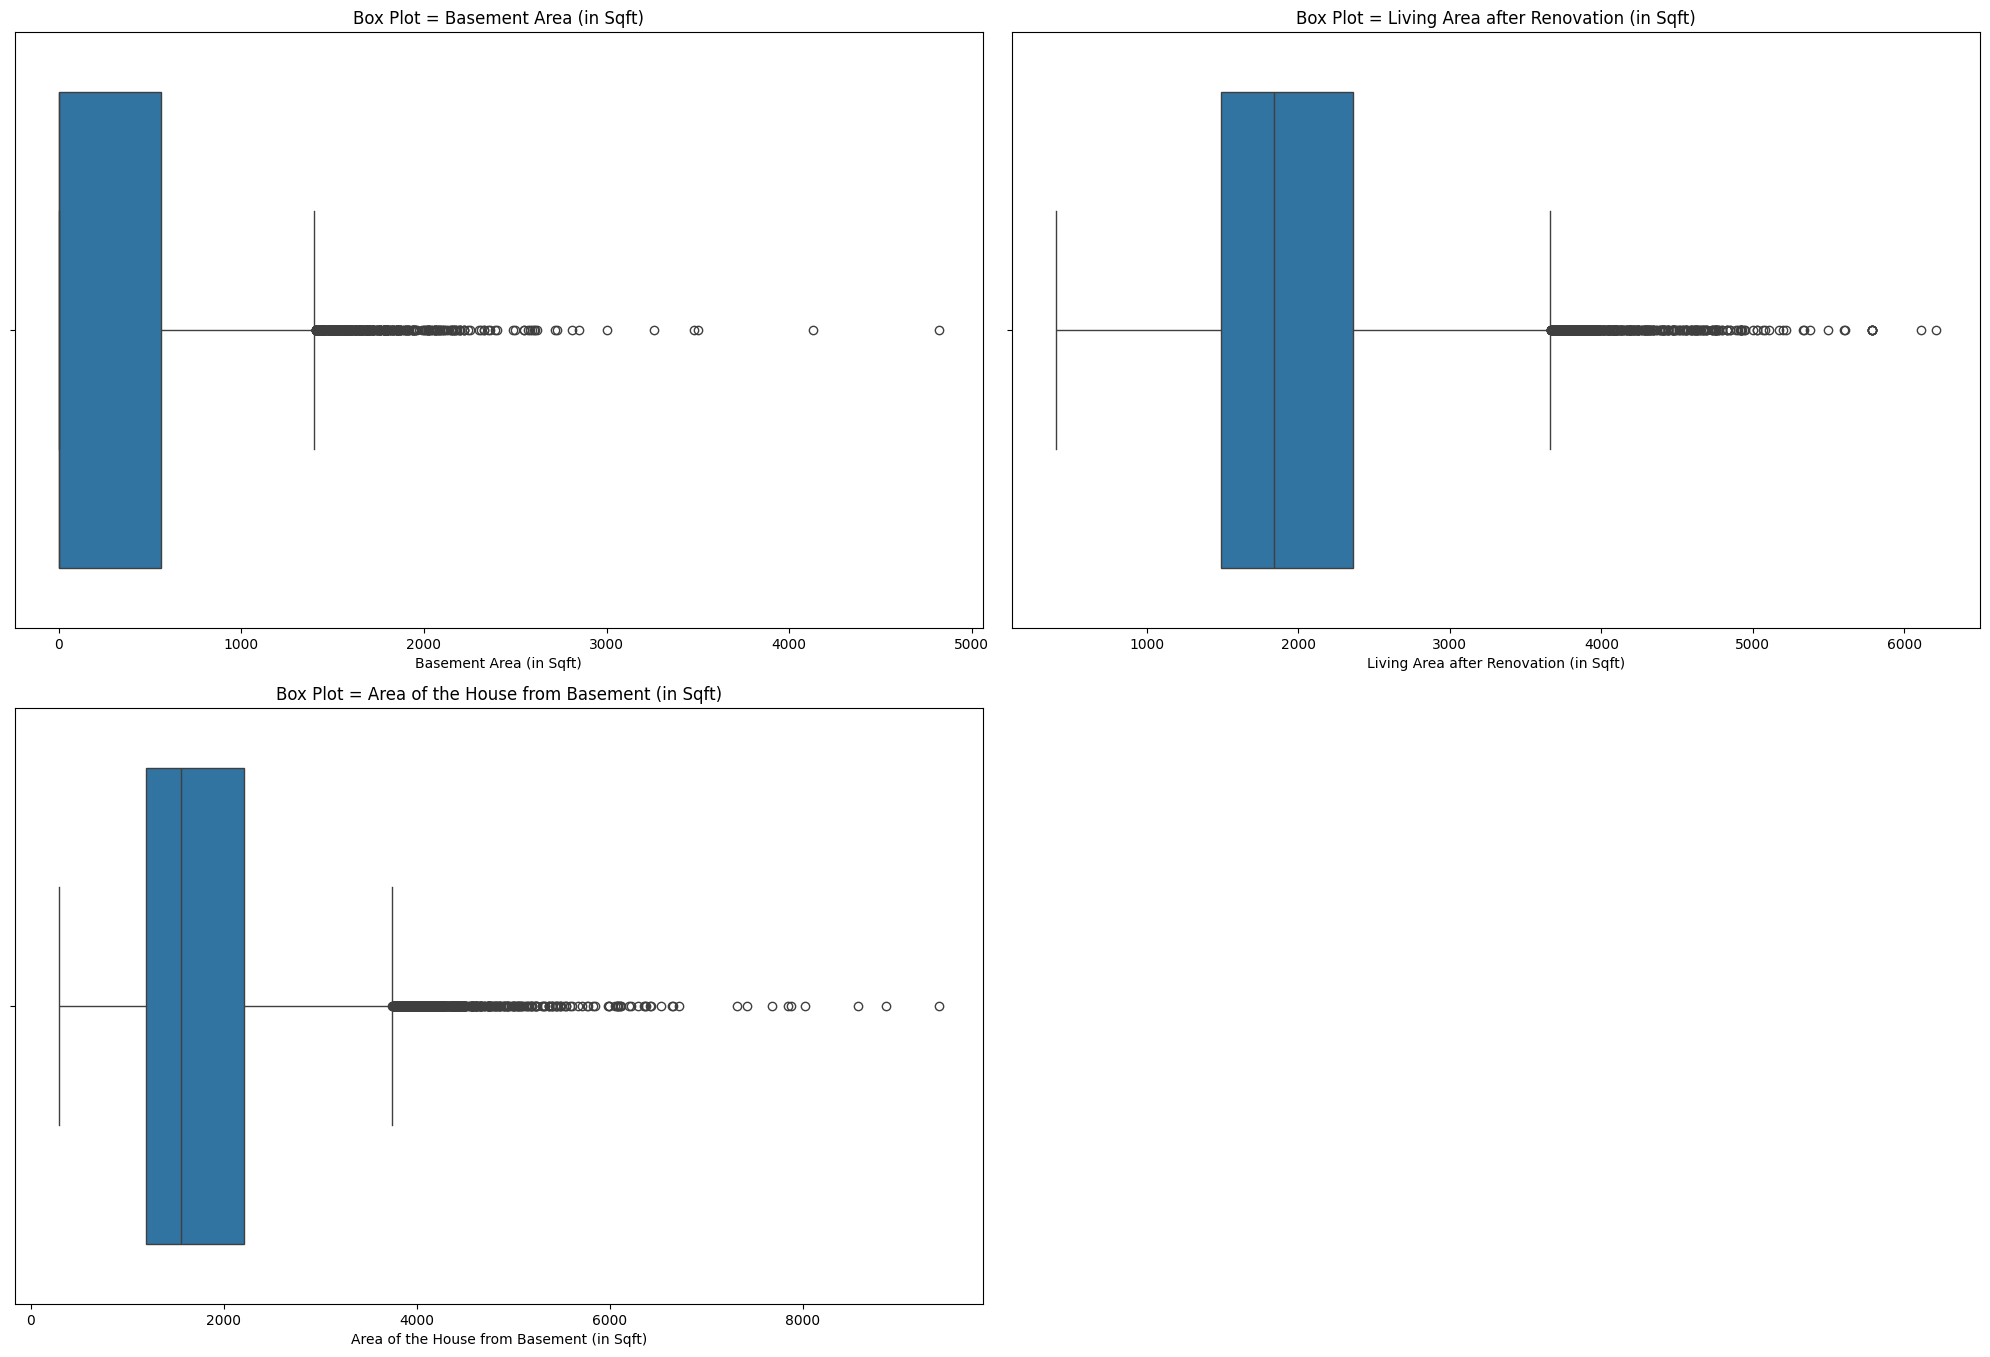

In [188]:
columns = columns_to_select
plt.figure(figsize=(20,20))

for i ,col in enumerate(columns):
  plt.subplot(len(columns), 2,i+1)
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot = {col}")

plt.tight_layout()
plt.show()

In [189]:
df.head(1)

,Sale Price,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Living Area after Renovation (in Sqft)
0,221900.0,1180.0,0,1340.0


In [194]:
#IQR Method
columns = [columns_to_select]

for cols in columns:
    q1 = df[cols].quantile(0.25)
    q3 = df[cols].quantile(0.75)

    IQR = q3 - q1

    upper_bound = q3 + 1.5 * IQR
    lower_bound = q1 - 1.5 * IQR

In [195]:
outlier = df[(df[cols] < lower_bound) |(df[cols] > upper_bound)]

Train-Test-Split

In [196]:
X=df.drop('Sale Price',axis=1)
y=df['Sale Price']


In [197]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

Scaling

In [202]:
#Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
